In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Read blocks data from parquet 

In [3]:
train_df =  pd.read_parquet('../data/raw/data_train.parquet')

--- Running Segmented ADF Test (40 chunks) ---
Chunk      | Start Index     | ADF Stat     | p-value    | Status
----------------------------------------------------------------------
1          | 0               | -55.7358     | 0.0000     | Stationary
2          | 172327          | -79.7549     | 0.0000     | Stationary
3          | 344654          | -52.3438     | 0.0000     | Stationary
4          | 516981          | -56.4159     | 0.0000     | Stationary
5          | 689308          | -58.1016     | 0.0000     | Stationary
6          | 861635          | -59.0758     | 0.0000     | Stationary
7          | 1033962         | -58.8989     | 0.0000     | Stationary
8          | 1206289         | -70.4937     | 0.0000     | Stationary
9          | 1378616         | -77.0532     | 0.0000     | Stationary
10         | 1550943         | -75.6953     | 0.0000     | Stationary
11         | 1723270         | -54.9605     | 0.0000     | Stationary
12         | 1895597         | -48.4849     | 

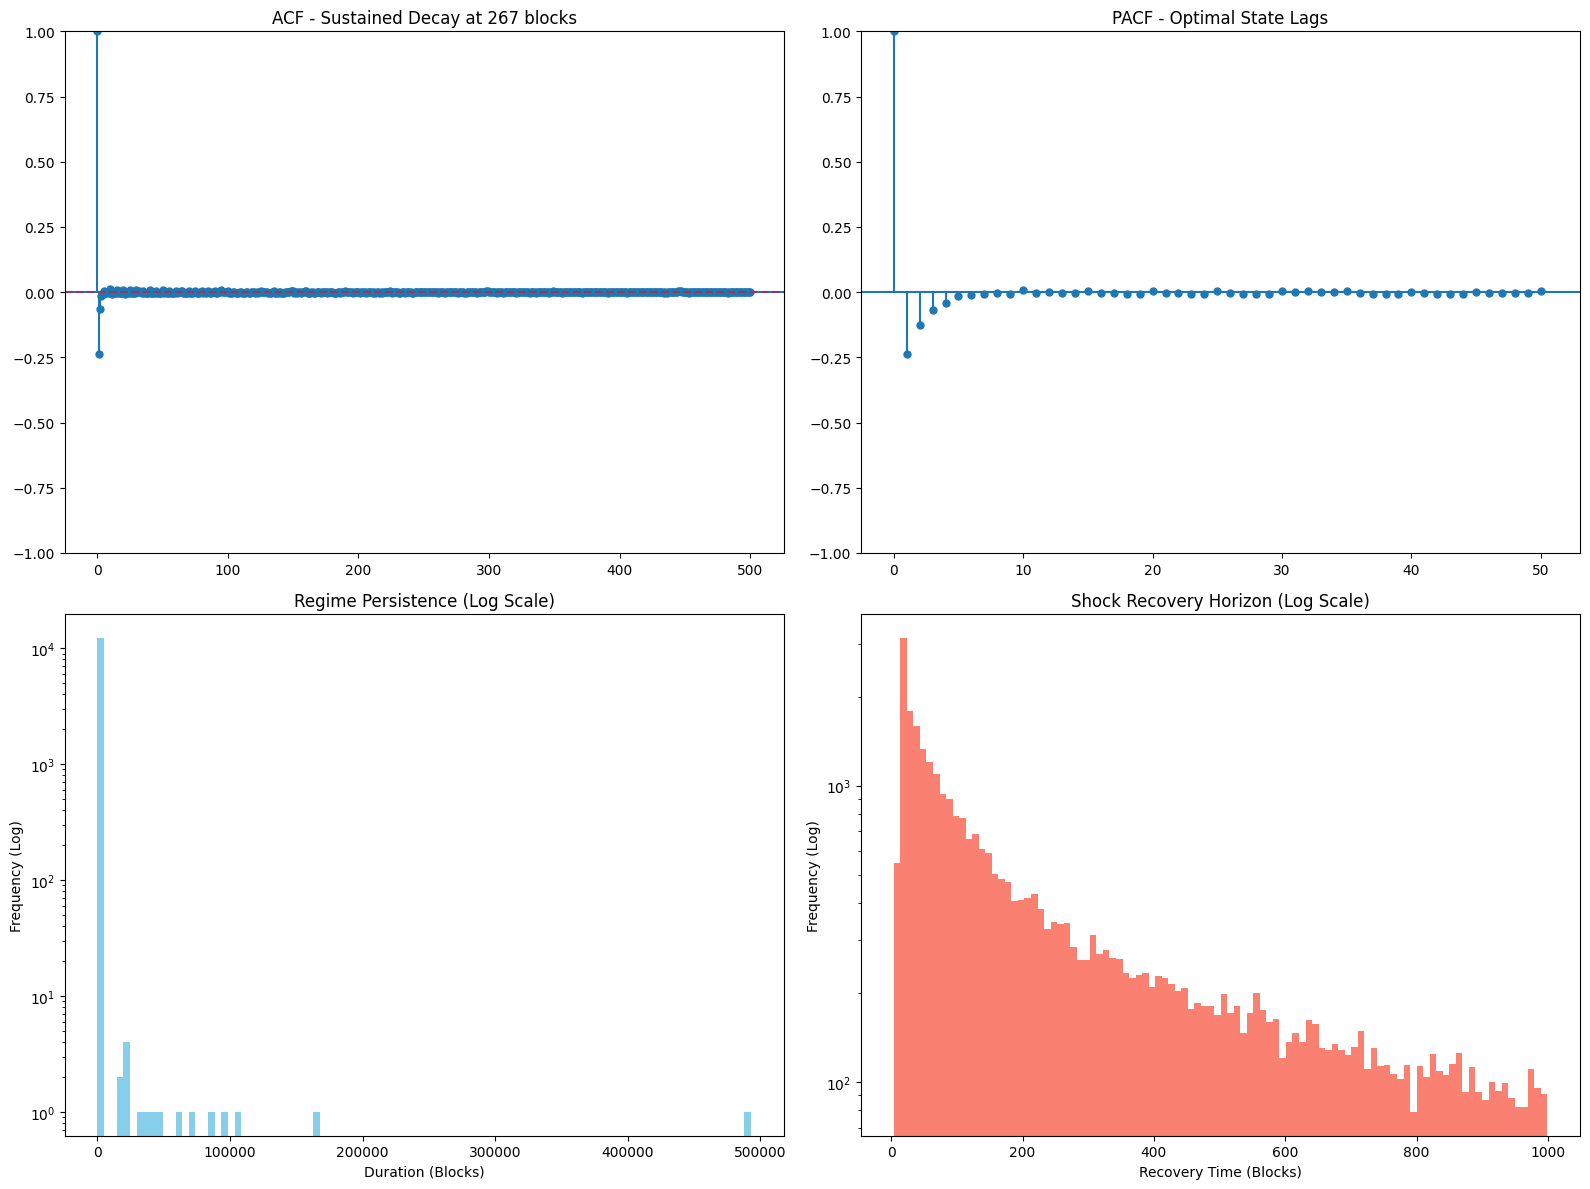


=== FINAL SCIENTIFIC SUMMARY ===
                  Method  Blocks
0    Sustained ACF Decay   267.0
1          Regime Median    11.0
2             Regime P90    51.0
3  Shock Recovery Median   151.0
4     Shock Recovery P90   690.0


In [4]:
# --- 1. SETUP (prevent LEAKAGE: only use TRAIN_DF) ---
# train_df already splited in previous step
sub_df = train_df[['base_fee_per_gas', 'gas_used']].copy()
target_gas = 15000000
# --- 2. SIGNAL PREPARATION (CLEAN & STATIONARY) ---
sub_df['u_smooth'] = (sub_df['gas_used'] / target_gas).rolling(window=50).mean() # 50 to prevent fake spike
sub_df['log_fee'] = np.log(sub_df['base_fee_per_gas'])
sub_df['returns'] = sub_df['log_fee'].diff()
returns_clean = sub_df['returns'].dropna()
# --- 3. STATIONARITY TEST (ADF TEST) ---
n_chunks = 40
chunk_size = len(returns_clean) // n_chunks
chunk_results = []
print(f"--- Running Segmented ADF Test ({n_chunks} chunks) ---")
print(f"{'Chunk':<10} | {'Start Index':<15} | {'ADF Stat':<12} | {'p-value':<10} | {'Status'}")
print("-" * 70)
for i in range(n_chunks):
    start_idx = i * chunk_size
    end_idx = (i + 1) * chunk_size
    
    # get chunks data
    chunk = returns_clean.iloc[start_idx:end_idx]
    
    # Run ADF for each chunk
    adf_stat, p_value, *_ = adfuller(chunk)
    
    status = "Stationary" if p_value < 0.05 else "Non-Stationary"
    chunk_results.append((adf_stat, p_value))
    
    print(f"{i+1:<10} | {start_idx:<15} | {adf_stat:<12.4f} | {p_value:<10.4f} | {status}")
# 2. Summary
avg_p = np.mean([r[1] for r in chunk_results])
print("-" * 70)
print(f"Final Conclusion: All chunks are stationary. Average p-value: {avg_p:.6f}")
# --- 4. STEP 1: SUSTAINED ACF DECAY ---
acf_values = acf(returns_clean, nlags=500)
conf_bound = 1.96 / np.sqrt(len(returns_clean))
acf_horizon = 500
# sustained for 5 blocks
for i in range(len(acf_values) - 5):
    if np.all(np.abs(acf_values[i:i+5]) < conf_bound):
        acf_horizon = i
        break
# --- 5. STEP 2: REGIME PERSISTENCE ---
threshold_high = sub_df['u_smooth'].quantile(0.75)
sub_df['is_high'] = sub_df['u_smooth'] > threshold_high
sub_df['group_id'] = (sub_df['is_high'] != sub_df['is_high'].shift()).cumsum()
regime_durations = sub_df[sub_df['is_high']].groupby('group_id').size()
regime_durations = regime_durations[regime_durations > 5] 
# --- 6. STEP 3: SUSTAINED SHOCK RECOVERY ---
sub_df['vol'] = sub_df['returns'].rolling(window=20).std()
vol_vals = sub_df['vol'].values
shock_threshold = sub_df['vol'].quantile(0.95)
recovery_threshold = sub_df['vol'].median()
sub_df['shock_start'] = (sub_df['vol'] > shock_threshold) & (~(sub_df['vol'].shift(1) > shock_threshold).fillna(False))
shock_indices = sub_df.index[sub_df['shock_start']].tolist()
recovery_durations = []
recovery_window = 10 # Need 10 blocks stable
for s_idx in shock_indices:
    end_s = min(s_idx + 1000, len(sub_df) - recovery_window)
    # inter thought to find stable point 
    for idx in range(s_idx, end_s):
        if np.all(vol_vals[idx : idx + recovery_window] < recovery_threshold):
            recovery_durations.append(idx - s_idx)
            break
            
recovery_durations = np.array(recovery_durations)
# --- 7. FINAL SUMMARY & VISUALIZATION ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Draw ACF (Memory Analysis)
plot_acf(returns_clean, lags=n_lags if 'n_lags' in locals() else 500, ax=axes[0,0], alpha=0.05)
axes[0,0].axhline(conf_bound, color='r', linestyle='--', alpha=0.5)
axes[0,0].set_title(f'ACF - Sustained Decay at {acf_horizon} blocks')

# 2. Draw PACF (State Lags Analysis)
plot_pacf(returns_clean, lags=50, ax=axes[0,1], alpha=0.05, method='ywm')
axes[0,1].set_title('PACF - Optimal State Lags')

# 3. Draw Regime Persistence (Log Scale to watch Long Tail)
axes[1,0].hist(regime_durations, bins=100, color='skyblue', log=True)
axes[1,0].set_title('Regime Persistence (Log Scale)')
axes[1,0].set_xlabel('Duration (Blocks)')
axes[1,0].set_ylabel('Frequency (Log)')

# 4. Draw Shock Recovery (Log Scale to watch Long Tail)
axes[1,1].hist(recovery_durations, bins=100, color='salmon', log=True)
axes[1,1].set_title('Shock Recovery Horizon (Log Scale)')
axes[1,1].set_xlabel('Recovery Time (Blocks)')
axes[1,1].set_ylabel('Frequency (Log)')

plt.tight_layout()
plt.show()

# Print Final Summary
summary_df = pd.DataFrame({
    "Method": ["Sustained ACF Decay", "Regime Median", "Regime P90", "Shock Recovery Median", "Shock Recovery P90"],
    "Blocks": [acf_horizon, regime_durations.median(), regime_durations.quantile(0.9), np.median(recovery_durations), np.percentile(recovery_durations, 90)]
})
print("\n=== FINAL SCIENTIFIC SUMMARY ===")
print(summary_df)


--- PACF Feature Engineering Analysis ---
Confidence Interval: +/- 0.00075
Significant Lags detected: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]
Suggested State Lags: 5 (Looking at the first 5 lags)


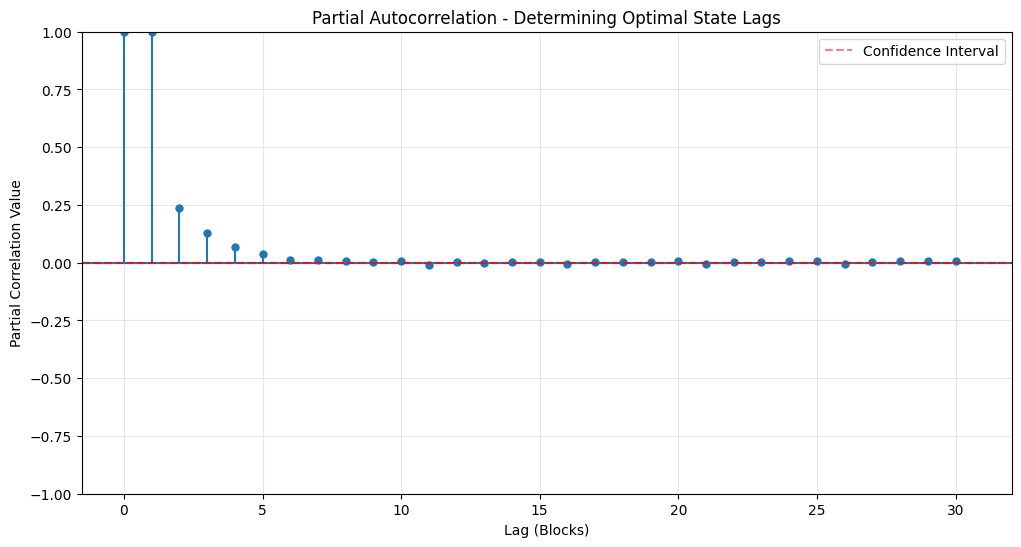

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf

sub_df['log_fee'] = np.log(sub_df['base_fee_per_gas'])

# 2. Caculate PACF
n_lags = 30
pacf_values = pacf(sub_df['log_fee'].dropna(), nlags=n_lags)
conf_interval = 1.96 / np.sqrt(len(sub_df))

# 3. Find significants Lags (not in trust interval)
significant_lags = np.where(np.abs(pacf_values) > conf_interval)[0]
# Pass lag 0 (always 1.0)
significant_lags = significant_lags[significant_lags > 0]

print(f"--- PACF Feature Engineering Analysis ---")
print(f"Confidence Interval: +/- {conf_interval:.5f}")
print(f"Significant Lags detected: {significant_lags}")
print(f"Suggested State Lags: {len(significant_lags[significant_lags <= 5])} (Looking at the first 5 lags)")

# 4. draw fig
fig, ax = plt.subplots(figsize=(12, 6))
plot_pacf(sub_df['log_fee'].dropna(), lags=n_lags, ax=ax, method='ywm')

ax.axhline(conf_interval, color='r', linestyle='--', alpha=0.5, label='Confidence Interval')
ax.axhline(-conf_interval, color='r', linestyle='--', alpha=0.5)
ax.set_title('Partial Autocorrelation - Determining Optimal State Lags')
ax.set_xlabel('Lag (Blocks)')
ax.set_ylabel('Partial Correlation Value')
ax.legend()

plt.grid(True, alpha=0.3)
plt.show()
